In [17]:
%matplotlib inline
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"

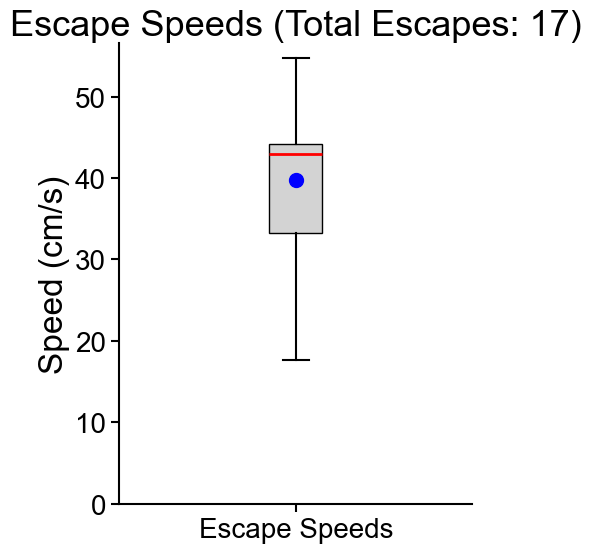

In [19]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

# Load escape objects for each session
JAL1_SEQ3_obj = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\escapes\escapes_obj.pkl"
with open(JAL1_SEQ3_obj, 'rb') as f:
    JAL1_SEQ3_escapes = pickle.load(f)

JAL1_SEQ2_obj = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_2_2023_03_14T08_11_32\processed_data\escapes\escapes_obj.pkl"
with open(JAL1_SEQ2_obj, 'rb') as f:
    JAL1_SEQ2_escapes = pickle.load(f)

JAL2_SEQ2_obj = r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_seq1_2_2023_04_25T07_32_30\processed_data\escapes\escapes_obj.pkl"
with open(JAL2_SEQ2_obj, 'rb') as f:
    JAL2_SEQ2_escapes = pickle.load(f)

JAL2_SEQ3_obj = r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_3_2023_04_28T08_31_30\processed_data\escapes\escapes_obj.pkl"
with open(JAL2_SEQ3_obj, 'rb') as f:
    JAL2_SEQ3_escapes = pickle.load(f)

# Escape objects for each session
sessions = {
    "JAL1_SEQ3": JAL1_SEQ3_escapes,
    "JAL1_SEQ2": JAL1_SEQ2_escapes,
    "JAL2_SEQ2": JAL2_SEQ2_escapes,
    "JAL2_SEQ3": JAL2_SEQ3_escapes,
}

# Collect all escape speeds across all sessions
all_escape_speeds = []
for session_name, escapes in sessions.items():
    # If avg_speed is a sequence, extend the list with all escape speeds
    if isinstance(escapes.avg_speed, (list, np.ndarray)):
        all_escape_speeds.extend(escapes.avg_speed)
    else:
        all_escape_speeds.append(escapes.avg_speed)  # Add scalar value directly

# Calculate the mean of all escape speeds
mean_speed = np.mean(all_escape_speeds)

# Get the total number of escapes
total_escapes = len(all_escape_speeds)

# Plot the results as a box plot
plt.rcParams.update({
    "font.size": 22,  # Larger font size for publication
    "font.family": "Arial",
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

fig, ax = plt.subplots(figsize=(5, 6))  # Adjusted figure size for less white space

# Create the box plot
box = ax.boxplot(all_escape_speeds, patch_artist=True, boxprops=dict(facecolor="lightgrey", color="black"), 
                 medianprops=dict(color="red", linewidth=2), whiskerprops=dict(color="black", linewidth=1.5), 
                 capprops=dict(color="black", linewidth=1.5), flierprops=dict(marker='o', color='black', alpha=0.5))

# Add the mean as a separate marker
ax.plot(1, mean_speed, marker='o', color='blue', markersize=10)

# Add labels and formatting
ax.set_title(f"Escape Speeds (Total Escapes: {total_escapes})")  # Add total escapes to the title
ax.set_ylabel("Speed (cm/s)")
ax.set_xticks([1])
ax.set_xticklabels(["Escape Speeds"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)
ax.tick_params(width=1.5, length=6)

# Set the Y-axis to start from 0
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(save_path, "speed_quantification.eps"), format='eps', bbox_inches='tight', dpi=300)